In [1]:
# =============================================================================
# DAY 9 — POWER BI DASHBOARD PREPARATION & BUILD GUIDE
# Project: Customer Churn Analytics & Prediction
# =============================================================================
# TASKS:
#   Task 1 — Load all project data & quick audit
#   Task 2 — Build KPI summary table
#   Task 3 — Build segment analysis tables (contract, internet, tenure, payment)
#   Task 4 — Build ML predictions table (for the churn risk view)
#   Task 5 — Build cohort & cross-segment tables
#   Task 6 — Export all tables to /outputs/powerbi/
#   Task 7 — Python preview dashboard (mirrors what Power BI will show)
#   Task 8 — Step-by-step Power BI build guide (printed to console)
# =============================================================================
# NOTE ON THIS DAY:
#   Power BI is a GUI tool — it cannot be driven by Python directly.
#   This script's job is to:
#     (a) Prepare all clean, structured tables that Power BI will import
#     (b) Create a Python matplotlib preview so you can see the design
#         before opening Power BI
#     (c) Print a detailed step-by-step guide for building in Power BI
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import joblib
import os
import warnings

warnings.filterwarnings("ignore")

# ── Plotting style ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi"      : 130,
    "axes.titlesize"  : 11,
    "axes.labelsize"  : 10,
    "xtick.labelsize" : 9,
    "ytick.labelsize" : 9,
    "legend.fontsize" : 9,
})

# Colour palette (consistent with Days 3–8)
CLR_RETAIN  = "#1D9E75"
CLR_CHURN   = "#E24B4A"
CLR_NEUT    = "#378ADD"
CLR_WARN    = "#F4A83A"
CLR_GREY    = "#9E9E9E"
CLR_PURPLE  = "#9B59B6"
CLR_DARK    = "#2C3E50"
CLR_FOREST  = "#2E7D32"
CLR_BOOST   = "#E65100"

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR      = "C:/Users/white/Downloads/Learn/Churn_project/data"
VISUALS_DIR   = "C:/Users/white/Downloads/Learn/Churn_project/visuals"
OUTPUTS_DIR   = "C:/Users/white/Downloads/Learn/Churn_project/outputs"
PBI_DIR       = "C:/Users/white/Downloads/Learn/Churn_project/outputs/powerbi"   # all Power BI import tables go here
MODELS_DIR    = "C:/Users/white/Downloads/Learn/Churn_project/models"

for d in [DATA_DIR, VISUALS_DIR, OUTPUTS_DIR, PBI_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

print("=" * 65)
print("  DAY 9 — POWER BI DASHBOARD PREPARATION & BUILD GUIDE")
print("=" * 65)


  DAY 9 — POWER BI DASHBOARD PREPARATION & BUILD GUIDE


In [2]:
# =============================================================================
# TASK 1 — LOAD ALL PROJECT DATA & QUICK AUDIT
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 1 — Load all project data")
print("=" * 65)

RAW_PATH   = f"{DATA_DIR}/WA_Fn-UseC_-Telco-Customer-Churn.csv"
CLEAN_PATH = f"{DATA_DIR}/churn_cleaned.csv"

df_raw   = pd.read_csv(RAW_PATH)
df_clean = pd.read_csv(CLEAN_PATH)
X_test   = pd.read_csv(f"{DATA_DIR}/X_test.csv")
y_test   = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze()
X_train  = pd.read_csv(f"{DATA_DIR}/X_train.csv")
y_train  = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze()

# Fix TotalCharges in raw df (for revenue calculations)
df_raw["TotalCharges"] = pd.to_numeric(df_raw["TotalCharges"].str.strip(), errors="coerce")
df_raw["TotalCharges"] = df_raw["TotalCharges"].fillna(0)
df_raw["ChurnFlag"]    = (df_raw["Churn"] == "Yes").astype(int)

print(f"\n  Raw dataset      : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"  Cleaned dataset  : {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print(f"  X_test           : {X_test.shape[0]:,} rows x {X_test.shape[1]} features")
print(f"  y_test churn rate: {y_test.mean()*100:.1f}%")

# ── 1b. Load final model & generate predictions ───────────────────────────────
MODEL_LOADED = False
try:
    final_model      = joblib.load(f"{MODELS_DIR}/final_model.pkl")
    feature_names    = joblib.load(f"{MODELS_DIR}/feature_names.pkl")
    metadata         = joblib.load(f"{MODELS_DIR}/model_metadata.pkl")
    y_prob_test      = final_model.predict_proba(X_test)[:, 1]
    optimal_thresh   = metadata["optimal_threshold"]
    y_pred_test      = (y_prob_test >= optimal_thresh).astype(int)
    model_name_short = metadata["model_name"]
    MODEL_LOADED     = True
    print(f"\n  Final model loaded : {model_name_short}")
    print(f"  Test ROC-AUC       : {metadata['test_metrics']['ROC-AUC']}")
    print(f"  Optimal threshold  : {optimal_thresh}")
except Exception as e:
    print(f"\n  Warning: Could not load model: {e}")
    print("  Continuing without ML predictions table.")

print("\n  Task 1 complete")


  TASK 1 — Load all project data

  Raw dataset      : 7,043 rows x 22 columns
  Cleaned dataset  : 7,043 rows x 49 columns
  X_test           : 1,409 rows x 39 features
  y_test churn rate: 26.5%

  Final model loaded : XGBoost
  Test ROC-AUC       : 0.8411
  Optimal threshold  : 0.49

  Task 1 complete


In [3]:
# =============================================================================
# TASK 2 — KPI SUMMARY TABLE
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 2 — Build KPI summary table")
print("=" * 65)

print("""
  Power BI KPI Cards will show these top-level numbers
  prominently at the top of the dashboard.
  We pre-compute them here so Power BI's DAX is minimal.
""")

total_customers     = len(df_raw)
total_churned       = int(df_raw["ChurnFlag"].sum())
total_retained      = total_customers - total_churned
churn_rate          = round(df_raw["ChurnFlag"].mean() * 100, 2)
retention_rate      = round(100 - churn_rate, 2)
total_monthly_rev   = round(df_raw["MonthlyCharges"].sum(), 2)
churned_monthly_rev = round(df_raw[df_raw["Churn"] == "Yes"]["MonthlyCharges"].sum(), 2)
revenue_at_risk_pct = round(churned_monthly_rev / total_monthly_rev * 100, 2)
avg_tenure_churned  = round(df_raw[df_raw["Churn"] == "Yes"]["tenure"].mean(), 1)
avg_tenure_retained = round(df_raw[df_raw["Churn"] == "No"]["tenure"].mean(),  1)
avg_monthly_churned = round(df_raw[df_raw["Churn"] == "Yes"]["MonthlyCharges"].mean(), 2)
avg_monthly_retained= round(df_raw[df_raw["Churn"] == "No"]["MonthlyCharges"].mean(),  2)
senior_churn_rate   = round(df_raw[df_raw["SeniorCitizen"] == 1]["ChurnFlag"].mean() * 100, 2)
mtm_churn_rate      = round(df_raw[df_raw["Contract"] == "Month-to-month"]["ChurnFlag"].mean() * 100, 2)

kpi_table = pd.DataFrame({
    "KPI"  : [
        "Total Customers",
        "Total Churned",
        "Total Retained",
        "Churn Rate (%)",
        "Retention Rate (%)",
        "Total Monthly Revenue ($)",
        "Monthly Revenue at Risk ($)",
        "Revenue at Risk (%)",
        "Avg Tenure - Churned (months)",
        "Avg Tenure - Retained (months)",
        "Avg Monthly Charge - Churned ($)",
        "Avg Monthly Charge - Retained ($)",
        "Senior Citizen Churn Rate (%)",
        "Month-to-Month Churn Rate (%)",
    ],
    "Value": [
        total_customers, total_churned, total_retained,
        churn_rate, retention_rate,
        total_monthly_rev, churned_monthly_rev, revenue_at_risk_pct,
        avg_tenure_churned, avg_tenure_retained,
        avg_monthly_churned, avg_monthly_retained,
        senior_churn_rate, mtm_churn_rate,
    ]
})

print("  KPI TABLE:")
print(f"  {'KPI':<38} {'Value':>15}")
print(f"  {'-'*38} {'-'*15}")
for _, row in kpi_table.iterrows():
    print(f"  {row['KPI']:<38} {str(row['Value']):>15}")

kpi_table.to_csv(f"{PBI_DIR}/pbi_kpi_summary.csv", index=False)
print(f"\n  Saved -> {PBI_DIR}/pbi_kpi_summary.csv")
print("\n  Task 2 complete")


  TASK 2 — Build KPI summary table

  Power BI KPI Cards will show these top-level numbers
  prominently at the top of the dashboard.
  We pre-compute them here so Power BI's DAX is minimal.

  KPI TABLE:
  KPI                                              Value
  -------------------------------------- ---------------
  Total Customers                                 7043.0
  Total Churned                                   1869.0
  Total Retained                                  5174.0
  Churn Rate (%)                                   26.54
  Retention Rate (%)                               73.46
  Total Monthly Revenue ($)                     456116.6
  Monthly Revenue at Risk ($)                  139130.85
  Revenue at Risk (%)                               30.5
  Avg Tenure - Churned (months)                     18.0
  Avg Tenure - Retained (months)                    37.6
  Avg Monthly Charge - Churned ($)                 74.44
  Avg Monthly Charge - Retained ($)                61

In [4]:
# =============================================================================
# TASK 3 — SEGMENT ANALYSIS TABLES
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 3 — Build segment analysis tables")
print("=" * 65)

def segment_table(df, group_col):
    """
    Groups by group_col, returns:
    Customers, Churned, Retained, Churn_Rate_Pct,
    Avg_Monthly_Charge, Total_Monthly_Rev, Avg_Tenure
    """
    result = df.groupby(group_col).agg(
        Customers          = ("ChurnFlag", "count"),
        Churned            = ("ChurnFlag", "sum"),
        Avg_Monthly_Charge = ("MonthlyCharges", "mean"),
        Total_Monthly_Rev  = ("MonthlyCharges", "sum"),
        Avg_Tenure         = ("tenure", "mean"),
    ).reset_index()
    result["Retained"]           = result["Customers"] - result["Churned"]
    result["Churn_Rate_Pct"]     = (result["Churned"] / result["Customers"] * 100).round(2)
    result["Avg_Monthly_Charge"] = result["Avg_Monthly_Charge"].round(2)
    result["Total_Monthly_Rev"]  = result["Total_Monthly_Rev"].round(2)
    result["Avg_Tenure"]         = result["Avg_Tenure"].round(1)
    return result.sort_values("Churn_Rate_Pct", ascending=False).reset_index(drop=True)


# ── 3a. By Contract ────────────────────────────────────────────────────────────
df_contract = segment_table(df_raw, "Contract")
print("\n  CONTRACT SEGMENT:")
print(df_contract.to_string(index=False))

# ── 3b. By Internet Service ────────────────────────────────────────────────────
df_internet = segment_table(df_raw, "InternetService")
print("\n  INTERNET SERVICE SEGMENT:")
print(df_internet.to_string(index=False))

# ── 3c. By Payment Method ──────────────────────────────────────────────────────
df_payment = segment_table(df_raw, "PaymentMethod")
print("\n  PAYMENT METHOD SEGMENT:")
print(df_payment.to_string(index=False))

# ── 3d. By Tenure Bucket ──────────────────────────────────────────────────────
bins   = [0, 12, 24, 36, 48, 60, 72]
labels = ["0-12 months", "13-24 months", "25-36 months",
          "37-48 months", "49-60 months", "61-72 months"]
df_raw["Tenure_Bucket"] = pd.cut(
    df_raw["tenure"], bins=bins, labels=labels, include_lowest=True
)
df_tenure = segment_table(df_raw, "Tenure_Bucket")
print("\n  TENURE BUCKET SEGMENT:")
print(df_tenure.to_string(index=False))

# ── 3e. By Senior Citizen ──────────────────────────────────────────────────────
df_raw["Senior_Label"] = df_raw["SeniorCitizen"].map({1: "Senior (65+)", 0: "Non-Senior"})
df_senior = segment_table(df_raw, "Senior_Label")
print("\n  SENIOR CITIZEN SEGMENT:")
print(df_senior.to_string(index=False))

# ── 3f. By Gender ──────────────────────────────────────────────────────────────
df_gender = segment_table(df_raw, "gender")
print("\n  GENDER SEGMENT:")
print(df_gender.to_string(index=False))

# ── 3g. By Partner + Dependents ───────────────────────────────────────────────
df_raw["Household"] = (df_raw["Partner"] + " Partner / "
                       + df_raw["Dependents"] + " Dependents")
df_household = segment_table(df_raw, "Household")
print("\n  HOUSEHOLD SEGMENT (Partner x Dependents):")
print(df_household.to_string(index=False))

# ── Save all segment tables ────────────────────────────────────────────────────
segment_tables = {
    "pbi_segment_contract"  : df_contract,
    "pbi_segment_internet"  : df_internet,
    "pbi_segment_payment"   : df_payment,
    "pbi_segment_tenure"    : df_tenure,
    "pbi_segment_senior"    : df_senior,
    "pbi_segment_gender"    : df_gender,
    "pbi_segment_household" : df_household,
}
for fname, table in segment_tables.items():
    path = f"{PBI_DIR}/{fname}.csv"
    table.to_csv(path, index=False)
    print(f"  Saved -> {path}")

print("\n  Task 3 complete")


  TASK 3 — Build segment analysis tables

  CONTRACT SEGMENT:
      Contract  Customers  Churned  Avg_Monthly_Charge  Total_Monthly_Rev  Avg_Tenure  Retained  Churn_Rate_Pct
Month-to-month       3875     1655               66.40          257294.15        18.0      2220           42.71
      One year       1473      166               65.05           95816.60        42.0      1307           11.27
      Two year       1695       48               60.77          103005.85        56.7      1647            2.83

  INTERNET SERVICE SEGMENT:
InternetService  Customers  Churned  Avg_Monthly_Charge  Total_Monthly_Rev  Avg_Tenure  Retained  Churn_Rate_Pct
    Fiber optic       3096     1297               91.50          283284.40        32.9      1799           41.89
            DSL       2421      459               58.10          140665.35        32.8      1962           18.96
             No       1526      113               21.08           32166.85        30.5      1413            7.40

  PAYME

In [5]:
# =============================================================================
# TASK 4 — ML PREDICTIONS TABLE
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 4 — Build ML predictions table")
print("=" * 65)

print("""
  This table pairs each test-set customer with:
    - Their actual label (churned / retained)
    - Model's predicted churn probability
    - Binary prediction at the optimal threshold
    - Risk tier: High (>=0.70) / Medium (0.40-0.69) / Low (<0.40)
    - Outcome label: TP / TN / FP / FN

  In Power BI this enables:
    - A risk scatter plot (probability vs monthly charge)
    - A high-risk customer count card
    - A risk tier breakdown bar chart
    - A confusion matrix table visual
""")

if MODEL_LOADED:
    predictions_df = X_test.copy()
    predictions_df["Actual_Churn"]      = y_test.values
    predictions_df["Churn_Probability"] = y_prob_test.round(4)
    predictions_df["Predicted_Churn"]   = y_pred_test
    predictions_df["Correct_Prediction"]= (
        (predictions_df["Actual_Churn"] == predictions_df["Predicted_Churn"])
        .astype(int)
    )

    def risk_tier(prob):
        if prob >= 0.70:   return "High Risk"
        elif prob >= 0.40: return "Medium Risk"
        else:              return "Low Risk"

    def outcome_label(row):
        a, p = row["Actual_Churn"], row["Predicted_Churn"]
        if   a == 1 and p == 1: return "True Positive (caught churner)"
        elif a == 0 and p == 0: return "True Negative (correct retain)"
        elif a == 0 and p == 1: return "False Positive (false alarm)"
        else:                   return "False Negative (missed churner)"

    predictions_df["Risk_Tier"]            = predictions_df["Churn_Probability"].apply(risk_tier)
    predictions_df["Outcome"]              = predictions_df.apply(outcome_label, axis=1)
    predictions_df["Monthly_Charge_Display"]= predictions_df.get(
        "MonthlyCharges_raw", predictions_df.get("MonthlyCharges", np.nan)
    )
    predictions_df["Tenure_Months_Display"] = predictions_df.get(
        "tenure_raw", predictions_df.get("tenure", np.nan)
    )

    risk_counts = predictions_df["Risk_Tier"].value_counts()
    print(f"  Total test customers   : {len(predictions_df):,}")
    print(f"  Churn prob range       : {predictions_df['Churn_Probability'].min():.4f} - "
          f"{predictions_df['Churn_Probability'].max():.4f}")
    print("\n  Risk tier distribution:")
    for tier, count in risk_counts.items():
        print(f"    {tier:<15} : {count:>5,}  ({count/len(predictions_df)*100:.1f}%)")

    print("\n  Outcome distribution:")
    for outcome, count in predictions_df["Outcome"].value_counts().items():
        print(f"    {outcome:<44} : {count:>5,}")

    predictions_df.to_csv(f"{PBI_DIR}/pbi_ml_predictions.csv", index=False)
    print(f"\n  Saved -> {PBI_DIR}/pbi_ml_predictions.csv")

    risk_summary = (
        predictions_df.groupby("Risk_Tier")
        .agg(
            Customers      = ("Actual_Churn", "count"),
            Actual_Churned = ("Actual_Churn", "sum"),
            Avg_Prob       = ("Churn_Probability", "mean"),
        )
        .reset_index()
    )
    risk_summary["Actual_Churn_Rate_Pct"] = (
        risk_summary["Actual_Churned"] / risk_summary["Customers"] * 100
    ).round(2)
    risk_summary["Avg_Prob"] = risk_summary["Avg_Prob"].round(4)
    risk_summary = risk_summary.sort_values("Avg_Prob", ascending=False)
    risk_summary.to_csv(f"{PBI_DIR}/pbi_risk_tier_summary.csv", index=False)
    print(f"  Saved -> {PBI_DIR}/pbi_risk_tier_summary.csv")
else:
    print("  Warning: Model not loaded - skipping ML predictions table.")
    print("  Run Day 8 script first to generate models/final_model.pkl")
    risk_counts = {}

print("\n  Task 4 complete")


  TASK 4 — Build ML predictions table

  This table pairs each test-set customer with:
    - Their actual label (churned / retained)
    - Model's predicted churn probability
    - Binary prediction at the optimal threshold
    - Risk tier: High (>=0.70) / Medium (0.40-0.69) / Low (<0.40)
    - Outcome label: TP / TN / FP / FN

  In Power BI this enables:
    - A risk scatter plot (probability vs monthly charge)
    - A high-risk customer count card
    - A risk tier breakdown bar chart
    - A confusion matrix table visual

  Total test customers   : 1,409
  Churn prob range       : 0.0012 - 0.9706

  Risk tier distribution:
    Low Risk        :   750  (53.2%)
    High Risk       :   338  (24.0%)
    Medium Risk     :   321  (22.8%)

  Outcome distribution:
    True Negative (correct retain)               :   760
    True Positive (caught churner)               :   297
    False Positive (false alarm)                 :   275
    False Negative (missed churner)              :    77



In [6]:
# =============================================================================
# TASK 5 — COHORT & CROSS-SEGMENT TABLES
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 5 — Build cohort & cross-segment tables")
print("=" * 65)

# ── 5a. Contract x Internet Service heatmap data ──────────────────────────────
cohort_ci = (
    df_raw.groupby(["Contract", "InternetService"])
    .agg(
        Customers   = ("ChurnFlag", "count"),
        Churned     = ("ChurnFlag", "sum"),
        Monthly_Rev = ("MonthlyCharges", "sum"),
    )
    .reset_index()
)
cohort_ci["Churn_Rate_Pct"] = (cohort_ci["Churned"] / cohort_ci["Customers"] * 100).round(2)
cohort_ci["Monthly_Rev"]    = cohort_ci["Monthly_Rev"].round(2)
cohort_ci.to_csv(f"{PBI_DIR}/pbi_cohort_contract_internet.csv", index=False)
print(f"  Saved -> {PBI_DIR}/pbi_cohort_contract_internet.csv")

# ── 5b. Monthly churn cohort (tenure month-by-month line chart) ───────────────
monthly_cohort = (
    df_raw.groupby("tenure")
    .agg(
        Customers   = ("ChurnFlag", "count"),
        Churned     = ("ChurnFlag", "sum"),
        Avg_Monthly = ("MonthlyCharges", "mean"),
    )
    .reset_index()
)
monthly_cohort["Churn_Rate_Pct"] = (
    monthly_cohort["Churned"] / monthly_cohort["Customers"] * 100
).round(2)
monthly_cohort["Avg_Monthly"] = monthly_cohort["Avg_Monthly"].round(2)
monthly_cohort.columns = [
    "Tenure_Month", "Customers", "Churned", "Avg_Monthly_Charge", "Churn_Rate_Pct"
]
monthly_cohort.to_csv(f"{PBI_DIR}/pbi_cohort_monthly_tenure.csv", index=False)
print(f"  Saved -> {PBI_DIR}/pbi_cohort_monthly_tenure.csv")

# ── 5c. Add-on services impact table ─────────────────────────────────────────
df_internet_only = df_raw[df_raw["InternetService"] != "No"].copy()
addon_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]
addon_rows = []
for col in addon_cols:
    for val in ["Yes", "No"]:
        sub = df_internet_only[df_internet_only[col] == val]
        if len(sub) == 0:
            continue
        addon_rows.append({
            "Service"       : col,
            "Subscribed"    : val,
            "Customers"     : len(sub),
            "Churned"       : int(sub["ChurnFlag"].sum()),
            "Churn_Rate_Pct": round(sub["ChurnFlag"].mean() * 100, 2),
            "Avg_Monthly"   : round(sub["MonthlyCharges"].mean(), 2),
        })
df_addons = pd.DataFrame(addon_rows)
df_addons.to_csv(f"{PBI_DIR}/pbi_addon_services.csv", index=False)
print(f"  Saved -> {PBI_DIR}/pbi_addon_services.csv")

# ── 5d. Revenue at risk by segment ───────────────────────────────────────────
churned_only = df_raw[df_raw["Churn"] == "Yes"]
rev_at_risk = (
    churned_only.groupby(["Contract", "InternetService"])
    .agg(
        Churned_Customers = ("ChurnFlag", "count"),
        Monthly_Rev_Lost  = ("MonthlyCharges", "sum"),
        Avg_Monthly_Lost  = ("MonthlyCharges", "mean"),
        Avg_Tenure        = ("tenure", "mean"),
    )
    .reset_index()
    .sort_values("Monthly_Rev_Lost", ascending=False)
    .reset_index(drop=True)
)
rev_at_risk["Monthly_Rev_Lost"] = rev_at_risk["Monthly_Rev_Lost"].round(2)
rev_at_risk["Avg_Monthly_Lost"] = rev_at_risk["Avg_Monthly_Lost"].round(2)
rev_at_risk["Avg_Tenure"]       = rev_at_risk["Avg_Tenure"].round(1)
rev_at_risk.to_csv(f"{PBI_DIR}/pbi_revenue_at_risk.csv", index=False)
print(f"  Saved -> {PBI_DIR}/pbi_revenue_at_risk.csv")

# ── 5e. Main enriched dataset (single source of truth for Power BI) ───────────
df_pbi_main = df_raw[[
    "customerID", "gender", "SeniorCitizen", "Senior_Label",
    "Partner", "Dependents", "Household",
    "tenure", "Tenure_Bucket",
    "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
    "MonthlyCharges", "TotalCharges",
    "Churn", "ChurnFlag"
]].copy()
df_pbi_main.to_csv(f"{PBI_DIR}/pbi_main_dataset.csv", index=False)
print(f"  Saved -> {PBI_DIR}/pbi_main_dataset.csv  ({df_pbi_main.shape[0]:,} rows x {df_pbi_main.shape[1]} cols)")

print("\n  All cohort & cross-segment tables exported")
print("\n  Task 5 complete")



  TASK 5 — Build cohort & cross-segment tables
  Saved -> C:/Users/white/Downloads/Learn/Churn_project/outputs/powerbi/pbi_cohort_contract_internet.csv
  Saved -> C:/Users/white/Downloads/Learn/Churn_project/outputs/powerbi/pbi_cohort_monthly_tenure.csv
  Saved -> C:/Users/white/Downloads/Learn/Churn_project/outputs/powerbi/pbi_addon_services.csv
  Saved -> C:/Users/white/Downloads/Learn/Churn_project/outputs/powerbi/pbi_revenue_at_risk.csv
  Saved -> C:/Users/white/Downloads/Learn/Churn_project/outputs/powerbi/pbi_main_dataset.csv  (7,043 rows x 25 cols)

  All cohort & cross-segment tables exported

  Task 5 complete


In [7]:
# =============================================================================
# TASK 6 — FILE INVENTORY
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 6 — Power BI file inventory")
print("=" * 65)

pbi_files = sorted([f for f in os.listdir(PBI_DIR) if f.endswith(".csv")])
total_size = 0
print(f"\n  Files in /outputs/powerbi/  ({len(pbi_files)} total)")
print(f"  {'File':<45} {'Rows':>8}  {'Cols':>6}")
print(f"  {'-'*45} {'-'*8}  {'-'*6}")
for fname in pbi_files:
    fpath = f"{PBI_DIR}/{fname}"
    try:
        tmp = pd.read_csv(fpath)
        fsize = os.path.getsize(fpath)
        total_size += fsize
        print(f"  {fname:<45} {tmp.shape[0]:>8,}  {tmp.shape[1]:>6}")
    except Exception:
        print(f"  {fname:<45}   (unreadable)")

print(f"\n  Total size: {total_size / 1024:.1f} KB")
print("\n  Task 6 complete")


  TASK 6 — Power BI file inventory

  Files in /outputs/powerbi/  (15 total)
  File                                              Rows    Cols
  --------------------------------------------- --------  ------
  pbi_addon_services.csv                              12       6
  pbi_cohort_contract_internet.csv                     9       6
  pbi_cohort_monthly_tenure.csv                       73       5
  pbi_kpi_summary.csv                                 14       2
  pbi_main_dataset.csv                             7,043      25
  pbi_ml_predictions.csv                           1,409      47
  pbi_revenue_at_risk.csv                              9       6
  pbi_risk_tier_summary.csv                            3       5
  pbi_segment_contract.csv                             3       8
  pbi_segment_gender.csv                               2       8
  pbi_segment_household.csv                            4       8
  pbi_segment_internet.csv                             3       8
  pbi_segmen


  TASK 7 — Python preview dashboard
  Building matplotlib version of the Power BI layout...


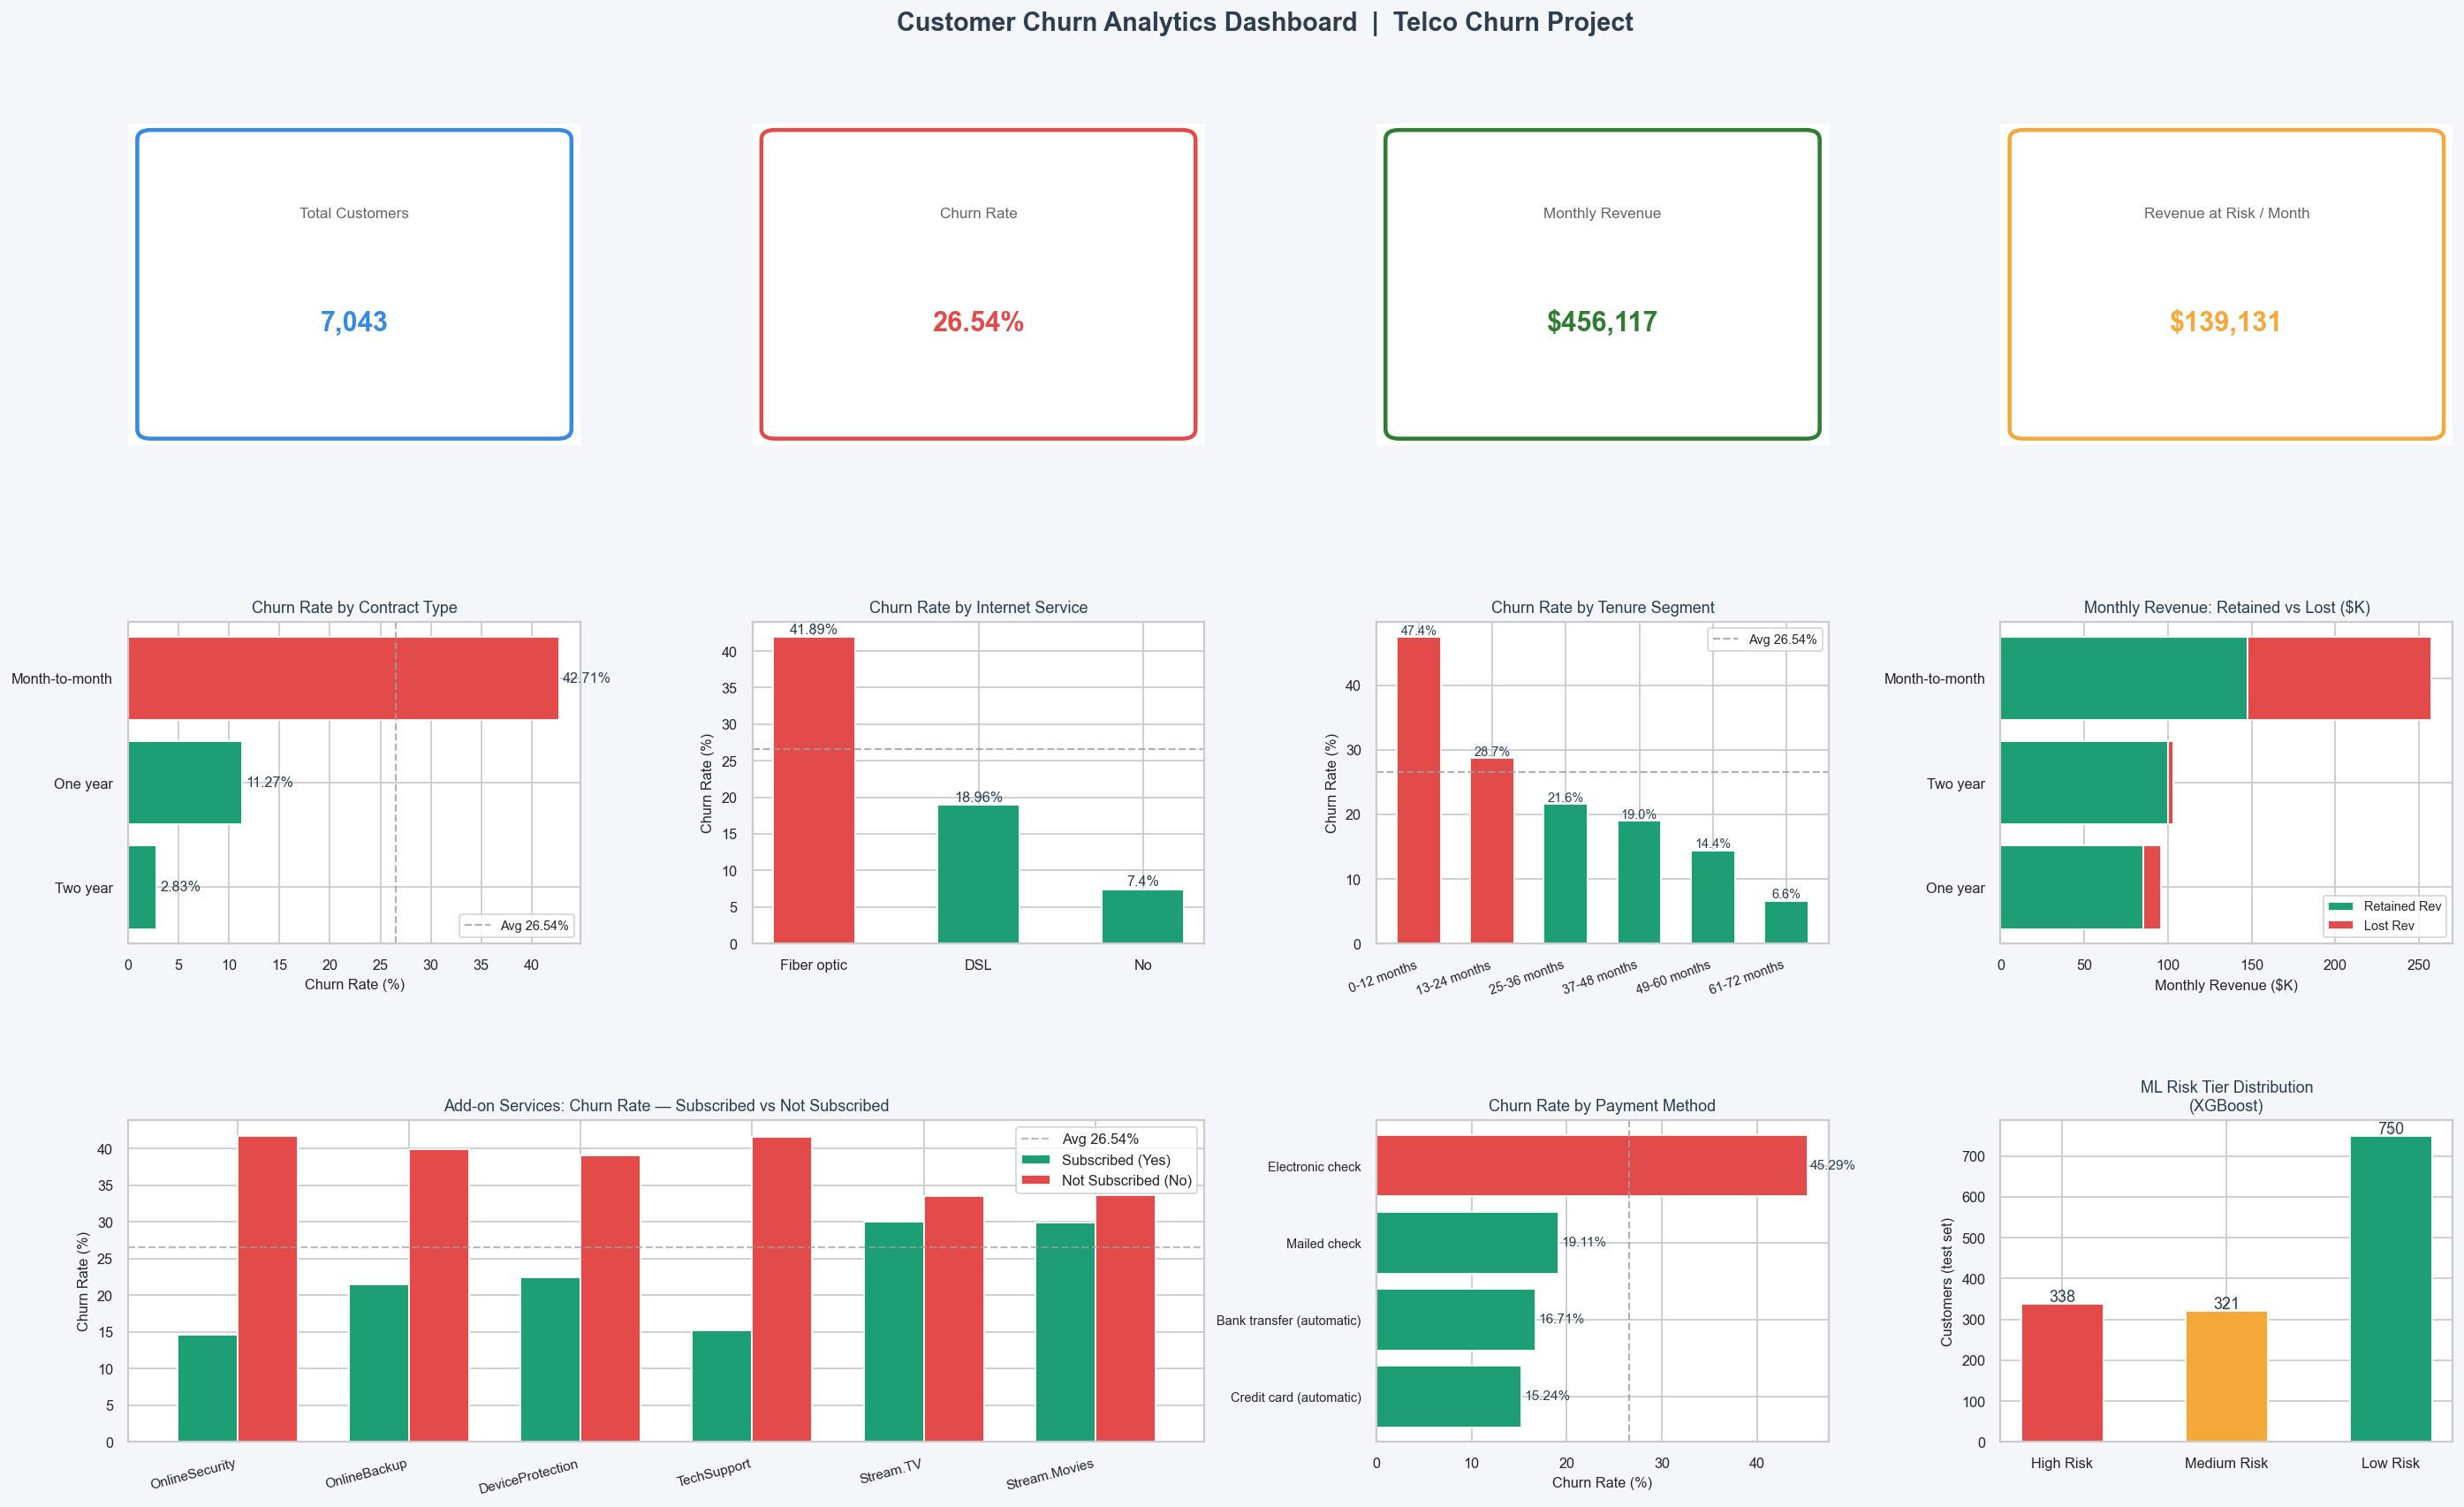


  Preview saved -> C:/Users/white/Downloads/Learn/Churn_project/visuals/day9_dashboard_preview.png

  Task 7 complete


In [8]:
# =============================================================================
# TASK 7 — PYTHON PREVIEW DASHBOARD
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 7 — Python preview dashboard")
print("=" * 65)
print("  Building matplotlib version of the Power BI layout...")

fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor("#F4F6F9")

gs = gridspec.GridSpec(
    3, 4,
    figure  = fig,
    hspace  = 0.55,
    wspace  = 0.38,
    top     = 0.88,
    bottom  = 0.06,
    left    = 0.05,
    right   = 0.97
)

fig.suptitle(
    "Customer Churn Analytics Dashboard  |  Telco Churn Project",
    fontsize=16, fontweight="bold", color=CLR_DARK, y=0.95
)

# ── KPI cards (Row 0 — 4 cards) ───────────────────────────────────────────────
kpi_axes = [fig.add_subplot(gs[0, i]) for i in range(4)]

kpi_data = [
    ("Total Customers",         f"{total_customers:,}",       CLR_NEUT),
    ("Churn Rate",              f"{churn_rate}%",              CLR_CHURN),
    ("Monthly Revenue",         f"${total_monthly_rev:,.0f}", CLR_FOREST),
    ("Revenue at Risk / Month", f"${churned_monthly_rev:,.0f}", CLR_WARN),
]

for ax, (title, value, color) in zip(kpi_axes, kpi_data):
    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.05, 0.05), 0.9, 0.9,
        boxstyle="round,pad=0.03",
        facecolor="white", edgecolor=color, linewidth=2.5,
        transform=ax.transAxes, zorder=0
    ))
    ax.text(0.5, 0.72, title,  ha="center", va="center",
            fontsize=9.5, color="#666", transform=ax.transAxes)
    ax.text(0.5, 0.38, value,  ha="center", va="center",
            fontsize=17, fontweight="bold", color=color, transform=ax.transAxes)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# ── Row 1 Col 0: Churn by Contract ────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1, 0])
ax1.set_facecolor("white")
contract_s = df_contract.sort_values("Churn_Rate_Pct")
bar_colors_c = [CLR_CHURN if r > 26.5 else CLR_RETAIN
                for r in contract_s["Churn_Rate_Pct"]]
ax1.barh(contract_s["Contract"], contract_s["Churn_Rate_Pct"],
         color=bar_colors_c, edgecolor="white")
ax1.axvline(churn_rate, color=CLR_GREY, lw=1.2, ls="--", alpha=0.8,
            label=f"Avg {churn_rate}%")
for i, v in enumerate(contract_s["Churn_Rate_Pct"]):
    ax1.text(v + 0.4, i, f"{v}%", va="center", fontsize=9, color=CLR_DARK)
ax1.set_title("Churn Rate by Contract Type", fontsize=10, color=CLR_DARK)
ax1.set_xlabel("Churn Rate (%)", fontsize=9)
ax1.legend(fontsize=8)

# ── Row 1 Col 1: Churn by Internet Service ───────────────────────────────────
ax2 = fig.add_subplot(gs[1, 1])
ax2.set_facecolor("white")
int_s = df_internet.sort_values("Churn_Rate_Pct", ascending=False)
bar_colors_i = [CLR_CHURN if r > 26.5 else CLR_RETAIN
                for r in int_s["Churn_Rate_Pct"]]
bars2 = ax2.bar(int_s["InternetService"], int_s["Churn_Rate_Pct"],
                color=bar_colors_i, edgecolor="white", width=0.5)
ax2.axhline(churn_rate, color=CLR_GREY, lw=1.2, ls="--", alpha=0.8)
for bar_obj, v in zip(bars2, int_s["Churn_Rate_Pct"]):
    ax2.text(bar_obj.get_x() + bar_obj.get_width() / 2,
             v + 0.5, f"{v}%", ha="center", fontsize=9, color=CLR_DARK)
ax2.set_title("Churn Rate by Internet Service", fontsize=10, color=CLR_DARK)
ax2.set_ylabel("Churn Rate (%)", fontsize=9)

# ── Row 1 Col 2: Churn by Tenure Bucket ──────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
ax3.set_facecolor("white")
tenure_s  = df_tenure.sort_values("Tenure_Bucket")
bar_colors_t = [CLR_CHURN if r > 26.5 else CLR_RETAIN
                for r in tenure_s["Churn_Rate_Pct"]]
bars3 = ax3.bar(range(len(tenure_s)), tenure_s["Churn_Rate_Pct"],
                color=bar_colors_t, edgecolor="white", width=0.6)
ax3.axhline(churn_rate, color=CLR_GREY, lw=1.2, ls="--", alpha=0.8,
            label=f"Avg {churn_rate}%")
ax3.set_xticks(range(len(tenure_s)))
ax3.set_xticklabels(tenure_s["Tenure_Bucket"].astype(str),
                    rotation=20, ha="right", fontsize=8)
for bar_obj, v in zip(bars3, tenure_s["Churn_Rate_Pct"]):
    ax3.text(bar_obj.get_x() + bar_obj.get_width() / 2,
             v + 0.4, f"{v:.1f}%", ha="center", fontsize=8, color=CLR_DARK)
ax3.set_title("Churn Rate by Tenure Segment", fontsize=10, color=CLR_DARK)
ax3.set_ylabel("Churn Rate (%)", fontsize=9)
ax3.legend(fontsize=8)

# ── Row 1 Col 3: Revenue at Risk (stacked bar) ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 3])
ax4.set_facecolor("white")
rev_c = df_contract.sort_values("Total_Monthly_Rev", ascending=True)
retained_rev = rev_c["Total_Monthly_Rev"] * (1 - rev_c["Churn_Rate_Pct"] / 100)
lost_rev     = rev_c["Total_Monthly_Rev"] * (rev_c["Churn_Rate_Pct"] / 100)
ax4.barh(rev_c["Contract"], retained_rev / 1000,
         color=CLR_RETAIN, label="Retained Rev", edgecolor="white")
ax4.barh(rev_c["Contract"], lost_rev / 1000,
         left=retained_rev / 1000, color=CLR_CHURN,
         label="Lost Rev", edgecolor="white")
ax4.set_title("Monthly Revenue: Retained vs Lost ($K)", fontsize=10, color=CLR_DARK)
ax4.set_xlabel("Monthly Revenue ($K)", fontsize=9)
ax4.legend(fontsize=8)

# ── Row 2 Col 0-1: Add-on services churn ────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :2])
ax5.set_facecolor("white")
addon_yes    = df_addons[df_addons["Subscribed"] == "Yes"].set_index("Service")
addon_no     = df_addons[df_addons["Subscribed"] == "No"].set_index("Service")
services     = [s for s in addon_yes.index if s in addon_no.index]
x = np.arange(len(services))
w = 0.35
bars_y = ax5.bar(x - w/2,
                 [addon_yes.loc[s, "Churn_Rate_Pct"] for s in services],
                 w, color=CLR_RETAIN, label="Subscribed (Yes)", edgecolor="white")
bars_n = ax5.bar(x + w/2,
                 [addon_no.loc[s, "Churn_Rate_Pct"] for s in services],
                 w, color=CLR_CHURN, label="Not Subscribed (No)", edgecolor="white")
ax5.axhline(churn_rate, color=CLR_GREY, lw=1.2, ls="--", alpha=0.7,
            label=f"Avg {churn_rate}%")
ax5.set_xticks(x)
ax5.set_xticklabels([s.replace("Streaming", "Stream.") for s in services],
                    rotation=15, ha="right", fontsize=8.5)
ax5.set_title("Add-on Services: Churn Rate — Subscribed vs Not Subscribed",
              fontsize=10, color=CLR_DARK)
ax5.set_ylabel("Churn Rate (%)", fontsize=9)
ax5.legend(fontsize=9)

# ── Row 2 Col 2: Payment method churn ────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
ax6.set_facecolor("white")
pay_s = df_payment.sort_values("Churn_Rate_Pct")
bar_colors_p = [CLR_CHURN if r > 26.5 else CLR_RETAIN
                for r in pay_s["Churn_Rate_Pct"]]
ax6.barh(pay_s["PaymentMethod"], pay_s["Churn_Rate_Pct"],
         color=bar_colors_p, edgecolor="white")
ax6.axvline(churn_rate, color=CLR_GREY, lw=1.2, ls="--", alpha=0.8)
for i, v in enumerate(pay_s["Churn_Rate_Pct"]):
    ax6.text(v + 0.3, i, f"{v}%", va="center", fontsize=8.5, color=CLR_DARK)
ax6.set_title("Churn Rate by Payment Method", fontsize=10, color=CLR_DARK)
ax6.set_xlabel("Churn Rate (%)", fontsize=9)
ax6.tick_params(axis="y", labelsize=8)

# ── Row 2 Col 3: ML risk tier or senior citizen ────────────────────────────────
ax7 = fig.add_subplot(gs[2, 3])
ax7.set_facecolor("white")
if MODEL_LOADED and len(risk_counts) > 0:
    risk_order  = ["High Risk", "Medium Risk", "Low Risk"]
    risk_colors = [CLR_CHURN, CLR_WARN, CLR_RETAIN]
    risk_vals   = [risk_counts.get(r, 0) for r in risk_order]
    bars7 = ax7.bar(risk_order, risk_vals, color=risk_colors,
                    edgecolor="white", width=0.5)
    for bar_obj, v in zip(bars7, risk_vals):
        ax7.text(bar_obj.get_x() + bar_obj.get_width() / 2,
                 v + 5, f"{v:,}", ha="center", fontsize=10, color=CLR_DARK)
    ax7.set_title(f"ML Risk Tier Distribution\n({model_name_short})",
                  fontsize=10, color=CLR_DARK)
    ax7.set_ylabel("Customers (test set)", fontsize=9)
else:
    # Fallback: senior citizen comparison
    sen_rates = df_senior.set_index("Senior_Label")["Churn_Rate_Pct"]
    labels_s  = sen_rates.index.tolist()
    colors_s  = [CLR_CHURN if r > 26.5 else CLR_RETAIN for r in sen_rates.values]
    bars_s = ax7.bar(labels_s, sen_rates.values, color=colors_s, edgecolor="white", width=0.4)
    for bar_obj, v in zip(bars_s, sen_rates.values):
        ax7.text(bar_obj.get_x() + bar_obj.get_width() / 2,
                 v + 0.5, f"{v}%", ha="center", fontsize=10, color=CLR_DARK)
    ax7.set_title("Churn Rate: Senior vs Non-Senior", fontsize=10, color=CLR_DARK)
    ax7.set_ylabel("Churn Rate (%)", fontsize=9)

plt.savefig(f"{VISUALS_DIR}/day9_dashboard_preview.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"\n  Preview saved -> {VISUALS_DIR}/day9_dashboard_preview.png")
print("\n  Task 7 complete")

In [9]:
# =============================================================================
# TASK 8 — STEP-BY-STEP POWER BI BUILD GUIDE
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 8 — POWER BI BUILD GUIDE")
print("=" * 65)

OPTIMAL_THRESH_STR = str(optimal_thresh) if MODEL_LOADED else "N/A"
AUC_STR = str(metadata["test_metrics"]["ROC-AUC"]) if MODEL_LOADED else "N/A"
MODEL_STR = model_name_short if MODEL_LOADED else "XGBoost"

print(f"""
  ================================================================
   POWER BI DASHBOARD — STEP-BY-STEP BUILD GUIDE
  ================================================================

  SOFTWARE NEEDED
  ───────────────
  Power BI Desktop (free download)
  URL: https://powerbi.microsoft.com/desktop/
  Sign in with any free Microsoft / Outlook account.

  ================================================================
  STEP 1 — IMPORT ALL CSV FILES
  ================================================================
  Home -> Get Data -> Text/CSV
  Import each file from /outputs/powerbi/ in this order:

    File                              Purpose in dashboard
    ─────────────────────────────────────────────────────────────
    pbi_main_dataset.csv              Primary fact table (all customers)
    pbi_kpi_summary.csv               KPI card source
    pbi_segment_contract.csv          Contract segment bar chart
    pbi_segment_internet.csv          Internet service bar chart
    pbi_segment_tenure.csv            Tenure bucket bar chart
    pbi_segment_payment.csv           Payment method bar chart
    pbi_segment_senior.csv            Senior citizen comparison
    pbi_addon_services.csv            Add-on services grouped bars
    pbi_cohort_contract_internet.csv  Matrix heatmap
    pbi_cohort_monthly_tenure.csv     Tenure cohort line chart
    pbi_revenue_at_risk.csv           Revenue at risk table
    pbi_ml_predictions.csv            ML scatter plot & risk tier
    pbi_risk_tier_summary.csv         Risk tier bar chart

  For each file: Home -> Get Data -> Text/CSV -> Load
  (Power BI will auto-detect "Use First Row as Headers")

  ================================================================
  STEP 2 — SET DATA TYPES IN POWER QUERY
  ================================================================
  Click Transform Data (Power Query Editor) after loading.

  In pbi_main_dataset:
    - tenure, SeniorCitizen, ChurnFlag  -> Whole Number
    - MonthlyCharges, TotalCharges      -> Decimal Number
    - customerID, all text columns      -> Text

  In pbi_ml_predictions:
    - Churn_Probability                 -> Decimal Number
    - Actual_Churn, Predicted_Churn     -> Whole Number

  In pbi_kpi_summary:
    - Value                             -> Decimal Number

  Click: Close & Apply

  ================================================================
  STEP 3 — PAGE 1: EXECUTIVE OVERVIEW
  ================================================================
  Right-click Pages panel -> Add Page -> Rename "Executive Overview"

  3a. TITLE
      Insert -> Text Box
      Text: "Customer Churn Analytics Dashboard"
      Font: Segoe UI  |  Size: 24  |  Bold  |  Colour: #2C3E50

  3b. SUBTITLE
      Insert -> Text Box
      Text: "Telco Customer Churn | 7,043 Customers | XGBoost Model"
      Font: 14  |  Colour: #9E9E9E

  3c. KPI CARDS (top row — 4 cards)
      Visualization: Card
      Source: pbi_kpi_summary.csv
      For each card, add a Visual Level Filter on KPI column:

        Card 1:  KPI = "Total Customers"
                 Format: Title="Total Customers", font bold, colour #378ADD

        Card 2:  KPI = "Churn Rate (%)"
                 Format: Title="Churn Rate", colour #E24B4A

        Card 3:  KPI = "Total Monthly Revenue ($)"
                 Format: Title="Monthly Revenue", colour #2E7D32

        Card 4:  KPI = "Monthly Revenue at Risk ($)"
                 Format: Title="Revenue at Risk / Month", colour #F4A83A

      Card styling tip: Format pane -> Background white, border 2px
      matching the card colour.

  3d. CLUSTERED BAR CHART: Churn by Contract Type
      Source: pbi_segment_contract.csv
      Y-axis: Contract  |  X-axis: Churn_Rate_Pct
      Data colours: Month-to-month=#E24B4A, One year=#F4A83A, Two year=#1D9E75
      Add constant line at {churn_rate} (Format -> Analytics -> Constant line)
      Title: "Churn Rate by Contract Type"

  3e. CLUSTERED COLUMN CHART: Churn by Internet Service
      Source: pbi_segment_internet.csv
      X-axis: InternetService  |  Y-axis: Churn_Rate_Pct
      Fibre optic=#E24B4A, DSL=#F4A83A, No=#1D9E75
      Add average line at {churn_rate}

  3f. CLUSTERED COLUMN CHART: Churn by Tenure Segment
      Source: pbi_segment_tenure.csv
      X-axis: Tenure_Bucket  |  Y-axis: Churn_Rate_Pct
      Tip: Sort X-axis by Tenure_Bucket column (not alphabetical)
      High churn bars (>26.5%) = red, else green

  3g. SLICER: Contract Type
      Field: Contract (from pbi_main_dataset)  |  Style: Dropdown
      This slicer will NOT affect the segment tables (they are
      pre-aggregated). It filters the main dataset only.
      To make slicers work across tables: use Edit Interactions.

  ================================================================
  STEP 4 — PAGE 2: REVENUE IMPACT
  ================================================================
  New page -> "Revenue Impact"

  4a. STACKED BAR CHART: Revenue Retained vs Lost by Contract
      Source: pbi_segment_contract.csv
      Y-axis: Contract
      Stack 1 (Retained Rev): compute as Total_Monthly_Rev * (1-Churn_Rate_Pct/100)
      Stack 2 (Lost Rev): Total_Monthly_Rev * (Churn_Rate_Pct/100)
      Tip: Create these as DAX measures if you want real-time slicer filtering.

      Simple approach (no DAX):
      Source: pbi_revenue_at_risk.csv
      Use Monthly_Rev_Lost directly for a bar chart sorted by revenue lost.

  4b. GROUPED BAR: Add-on Services Churn Comparison
      Source: pbi_addon_services.csv
      X-axis: Service
      Y-axis: Churn_Rate_Pct
      Legend: Subscribed (Yes=green, No=red)
      Story: Every add-on WITHOUT which customers churn ~2x more

  4c. TABLE VISUAL: Top Revenue-at-Risk Segments
      Source: pbi_revenue_at_risk.csv
      Columns: Contract, InternetService, Churned_Customers,
               Monthly_Rev_Lost, Avg_Monthly_Lost
      Sort: Monthly_Rev_Lost descending
      Add conditional formatting (data bars) on Monthly_Rev_Lost

  4d. SMALL KPI CARDS:
      "Revenue at Risk (%)"  = {revenue_at_risk_pct}%
      "Avg Monthly Charge — Churned ($)" = ${avg_monthly_churned}
      "Avg Monthly Charge — Retained ($)" = ${avg_monthly_retained}

  ================================================================
  STEP 5 — PAGE 3: CUSTOMER SEGMENTS
  ================================================================
  New page -> "Customer Segments"

  5a. DONUT CHART: Overall Churn vs Retained
      Source: pbi_main_dataset
      Values: ChurnFlag (Count or Sum)
      Legend: Churn
      Colours: No=#1D9E75, Yes=#E24B4A

  5b. CLUSTERED BAR: Churn by Payment Method
      Source: pbi_segment_payment.csv
      Y-axis: PaymentMethod  |  X-axis: Churn_Rate_Pct

  5c. MATRIX VISUAL: Contract x Internet Service Heatmap
      Source: pbi_cohort_contract_internet.csv
      Rows: Contract  |  Columns: InternetService  |  Values: Churn_Rate_Pct
      Format -> Conditional formatting -> Background colour
      Colour scale: white (low) to #E24B4A (high)
      This creates the heatmap effect without any custom visuals.

  5d. LINE CHART: Churn Rate Along Tenure Journey
      Source: pbi_cohort_monthly_tenure.csv
      X: Tenure_Month  |  Y: Churn_Rate_Pct
      Add a trend line: Format -> Analytics -> Trend line
      Story: Sharp decline from month 1 onwards. After 12 months,
             churn rate falls below average.

  5e. CLUSTERED BAR: Senior vs Non-Senior
      Source: pbi_segment_senior.csv

  5f. SLICERS: Contract, InternetService, gender, Senior_Label

  ================================================================
  STEP 6 — PAGE 4: ML PREDICTIONS (ADVANCED)
  ================================================================
  New page -> "Churn Risk Model"

  6a. CLUSTERED BAR: Risk Tier Distribution
      Source: pbi_risk_tier_summary.csv
      X: Risk_Tier  |  Y: Customers
      Colours: High Risk=#E24B4A, Medium Risk=#F4A83A, Low Risk=#1D9E75
      Add data labels showing actual count and churn rate

  6b. SCATTER CHART: Churn Probability vs Monthly Charge
      Source: pbi_ml_predictions.csv
      X-axis: Monthly_Charge_Display
      Y-axis: Churn_Probability
      Legend: Risk_Tier  (colour-coded)
      Size: constant or Tenure_Months_Display
      Add a horizontal reference line at {OPTIMAL_THRESH_STR} (decision threshold)
      Story: High-risk customers cluster top-right (high charge + high prob)

  6c. TABLE: High-Risk Customer List
      Source: pbi_ml_predictions.csv
      Visual level filter: Risk_Tier = "High Risk"
      Sort: Churn_Probability descending
      Columns: Churn_Probability, Actual_Churn, Risk_Tier, Outcome

  6d. KPI CARDS:
      "High Risk Customers"  — filter pbi_ml_predictions on Risk_Tier="High Risk"
      "Churners Correctly Caught" — filter Outcome contains "True Positive"

  6e. MODEL INFO TEXT BOX:
      "Model: {MODEL_STR}
       ROC-AUC: {AUC_STR}
       Decision Threshold: {OPTIMAL_THRESH_STR}
       Training Set: {len(X_train):,} customers"

  ================================================================
  STEP 7 — COLOUR GUIDE (match Python visuals)
  ================================================================
  Churned / High Risk    : #E24B4A  (red)
  Retained / Low Risk    : #1D9E75  (green)
  Neutral / Blue         : #378ADD  (blue)
  Warning / Medium Risk  : #F4A83A  (orange)
  Background             : #F4F6F9  (light grey)
  Text / Dark            : #2C3E50  (dark navy)

  To apply in Power BI:
    Format pane -> Data colours -> Custom colour -> paste hex

  ================================================================
  STEP 8 — PUBLISH & SHARE
  ================================================================
  8a. File -> Publish -> Publish to Power BI
  8b. Sign in with free Microsoft / Outlook account
  8c. Choose "My Workspace" -> Click Publish

  8d. In Power BI Service (browser):
      Open report -> Share (top right) -> Publish to web (public)
      -> Generate embed code -> Copy the shareable link

  8e. Add the link to:
      -> GitHub README.md:
         "Live Dashboard: [Power BI](your-link-here)"
      -> Resume bullet:
         "Built a 4-page Power BI dashboard with KPI cards,
          churn segment analysis, and ML risk tier scatter plot.
          Published to Power BI Service: [link]"
      -> LinkedIn project section

  ================================================================
  STEP 9 — SAVE & GIT COMMIT
  ================================================================
  In your terminal:

    git add outputs/powerbi/*.csv
    git add visuals/day9_dashboard_preview.png
    git add notebooks/day9_powerbi_prep.py  (or wherever you save this)
    git commit -m "Day 9: Power BI data prep - 13 tables exported to /outputs/powerbi"
    git push

  After building in Power BI:
    -> Screenshot the dashboard
    -> Save as visuals/day9_powerbi_screenshot.png
    git add visuals/day9_powerbi_screenshot.png
    git commit -m "Day 9: Power BI dashboard complete"
    git push
""")


  TASK 8 — POWER BI BUILD GUIDE

   POWER BI DASHBOARD — STEP-BY-STEP BUILD GUIDE

  SOFTWARE NEEDED
  ───────────────
  Power BI Desktop (free download)
  URL: https://powerbi.microsoft.com/desktop/
  Sign in with any free Microsoft / Outlook account.

  STEP 1 — IMPORT ALL CSV FILES
  Home -> Get Data -> Text/CSV
  Import each file from /outputs/powerbi/ in this order:

    File                              Purpose in dashboard
    ─────────────────────────────────────────────────────────────
    pbi_main_dataset.csv              Primary fact table (all customers)
    pbi_kpi_summary.csv               KPI card source
    pbi_segment_contract.csv          Contract segment bar chart
    pbi_segment_internet.csv          Internet service bar chart
    pbi_segment_tenure.csv            Tenure bucket bar chart
    pbi_segment_payment.csv           Payment method bar chart
    pbi_segment_senior.csv            Senior citizen comparison
    pbi_addon_services.csv            Add-on services

In [10]:
# =============================================================================
# FINAL SUMMARY
# =============================================================================
print("=" * 65)
print("  DAY 9 COMPLETE — KEY DELIVERABLES")
print("=" * 65)
print(f"""
  FILES EXPORTED TO /outputs/powerbi/  ({len(pbi_files)} CSVs)
    pbi_main_dataset.csv              : {total_customers:,} rows, all features + labels
    pbi_kpi_summary.csv               : {len(kpi_table)} top-level KPI values
    pbi_segment_*.csv (x7)            : Segment breakdown tables
    pbi_cohort_*.csv  (x2)            : Cohort analysis tables
    pbi_addon_services.csv            : 6 add-ons x subscribed / not
    pbi_revenue_at_risk.csv           : Revenue lost by contract x internet
    pbi_ml_predictions.csv            : {"ML risk scores + outcomes" if MODEL_LOADED else "skipped (run Day 8 first)"}
    pbi_risk_tier_summary.csv         : {"3 risk tiers" if MODEL_LOADED else "skipped"}

  CHART SAVED
    visuals/day9_dashboard_preview.png

  KEY METRICS FOR DASHBOARD
    Churn rate           : {churn_rate}%
    Revenue at risk/mo   : ${churned_monthly_rev:,.0f}  ({revenue_at_risk_pct}% of total)
    Month-to-month churn : {mtm_churn_rate}%  vs Two Year: ~3%
    Avg tenure (churned) : {avg_tenure_churned} months  vs {avg_tenure_retained} months (retained)

  TOMORROW — Day 10 (Streamlit App):
    -> Build interactive churn prediction app in Streamlit
    -> User inputs customer features via sidebar sliders
    -> App loads final_model.pkl and shows:
         - Churn probability gauge (0-100%)
         - Risk tier badge
         - SHAP waterfall chart for that customer
         - Recommended action (retention offer or no action)
    -> Deploy to Streamlit Cloud (free) -> live public URL
    -> Add URL to resume, GitHub README, LinkedIn
""")
print("=" * 65)

  DAY 9 COMPLETE — KEY DELIVERABLES

  FILES EXPORTED TO /outputs/powerbi/  (15 CSVs)
    pbi_main_dataset.csv              : 7,043 rows, all features + labels
    pbi_kpi_summary.csv               : 14 top-level KPI values
    pbi_segment_*.csv (x7)            : Segment breakdown tables
    pbi_cohort_*.csv  (x2)            : Cohort analysis tables
    pbi_addon_services.csv            : 6 add-ons x subscribed / not
    pbi_revenue_at_risk.csv           : Revenue lost by contract x internet
    pbi_ml_predictions.csv            : ML risk scores + outcomes
    pbi_risk_tier_summary.csv         : 3 risk tiers

  CHART SAVED
    visuals/day9_dashboard_preview.png

  KEY METRICS FOR DASHBOARD
    Churn rate           : 26.54%
    Revenue at risk/mo   : $139,131  (30.5% of total)
    Month-to-month churn : 42.71%  vs Two Year: ~3%
    Avg tenure (churned) : 18.0 months  vs 37.6 months (retained)

  TOMORROW — Day 10 (Streamlit App):
    -> Build interactive churn prediction app in Streamli